## Imports

In [1]:
import os
import cv2
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 12,
    'figure.titlesize': 14,
    'figure.titleweight': 'bold',
})

## Data Exploration

In [2]:
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/saralaidani
/kaggle/input/datasets/saralaidani/dibcode
/kaggle/input/datasets/saralaidani/dibcode/DIBCO
/kaggle/input/datasets/saralaidani/dibcode/DIBCO/Dataset
/kaggle/input/datasets/saralaidani/dibcode/DIBCO/GT


## Preprocessing

In [3]:
DATASET_INPUT_DIR  = "/kaggle/input/datasets/saralaidani/dibcode/DIBCO/Dataset"
GT_INPUT_DIR       = "/kaggle/input/datasets/saralaidani/dibcode/DIBCO/GT"
DATASET_OUTPUT_DIR = "/kaggle/working/preprocessed_dataset"
GT_OUTPUT_DIR      = "/kaggle/working/preprocessed_gt"
TARGET_SIZE        = (256, 256)
IMAGE_EXTENSIONS   = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

os.makedirs(DATASET_OUTPUT_DIR, exist_ok=True)
os.makedirs(GT_OUTPUT_DIR, exist_ok=True)

def normalize_background(gray):
    """Divide by a heavily blurred background estimate to flatten uneven illumination."""
    background = cv2.GaussianBlur(gray, (51, 51), 0).astype(np.float32)
    normalized = (gray.astype(np.float32) / (background + 1e-6)) * 128
    return np.clip(normalized, 0, 255).astype(np.uint8)

def preprocess_image(file_path):
    img = cv2.imread(file_path)
    if img is None:
        return None
    gray       = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized    = cv2.resize(gray, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    denoised   = cv2.fastNlMeansDenoising(resized, h=10, templateWindowSize=7, searchWindowSize=21)
    normalized = normalize_background(denoised)  # FIX: flatten background stains
    return normalized

def preprocess_gt(file_path):
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    resized = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_NEAREST)
    _, binary = cv2.threshold(resized, 127, 255, cv2.THRESH_BINARY)
    return binary

def get_image_files(directory):
    return sorted([
        os.path.join(root, f)
        for root, _, files in os.walk(directory)
        for f in files if f.lower().endswith(IMAGE_EXTENSIONS)
    ])

# Process dataset images
print("Processing Dataset images...")
count = 0
for file_path in tqdm(get_image_files(DATASET_INPUT_DIR)):
    result = preprocess_image(file_path)
    if result is not None:
        cv2.imwrite(os.path.join(DATASET_OUTPUT_DIR, f"img_{count:04d}.png"), result)
        count += 1
print(f"Dataset done: {count} images")

# Process GT images
print("\nProcessing GT images...")
count = 0
for file_path in tqdm(get_image_files(GT_INPUT_DIR)):
    result = preprocess_gt(file_path)
    if result is not None:
        cv2.imwrite(os.path.join(GT_OUTPUT_DIR, f"gt_{count:04d}.png"), result)
        count += 1
print(f"GT done: {count} images")

Processing Dataset images...


 76%|███████▋  | 104/136 [00:14<00:05,  5.79it/s][ WARN:0@15.137] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 18246 (0x4746) encountered
[ WARN:0@15.137] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 18249 (0x4749) encountered
[ WARN:0@15.137] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
100%|██████████| 136/136 [00:18<00:00,  7.42it/s]


Dataset done: 136 images

Processing GT images...


100%|██████████| 136/136 [00:03<00:00, 43.76it/s]

GT done: 136 images


## Verify Preprocessed Data

In [4]:
DATASET_DIR = "/kaggle/working/preprocessed_dataset"
GT_DIR      = "/kaggle/working/preprocessed_gt"

dataset_files = sorted(os.listdir(DATASET_DIR))
gt_files      = sorted(os.listdir(GT_DIR))
print(f"Dataset files: {len(dataset_files)}")
print(f"GT files:      {len(gt_files)}")

# Check first image shapes and value ranges
img = cv2.imread(os.path.join(DATASET_DIR, dataset_files[0]), cv2.IMREAD_GRAYSCALE)
gt  = cv2.imread(os.path.join(GT_DIR,      gt_files[0]),      cv2.IMREAD_GRAYSCALE)
if img is None or gt is None:
    raise RuntimeError("Could not load sample images — check preprocessing ran successfully.")

print(f"\nDataset image shape: {img.shape}")
print(f"GT image shape:      {gt.shape}")
print(f"Dataset pixel range: min={img.min()}, max={img.max()}")
print(f"GT unique values:    {np.unique(gt)}")

Dataset files: 136
GT files:      136

Dataset image shape: (256, 256)
GT image shape:      (256, 256)
Dataset pixel range: min=0, max=191
GT unique values:    [  0 255]


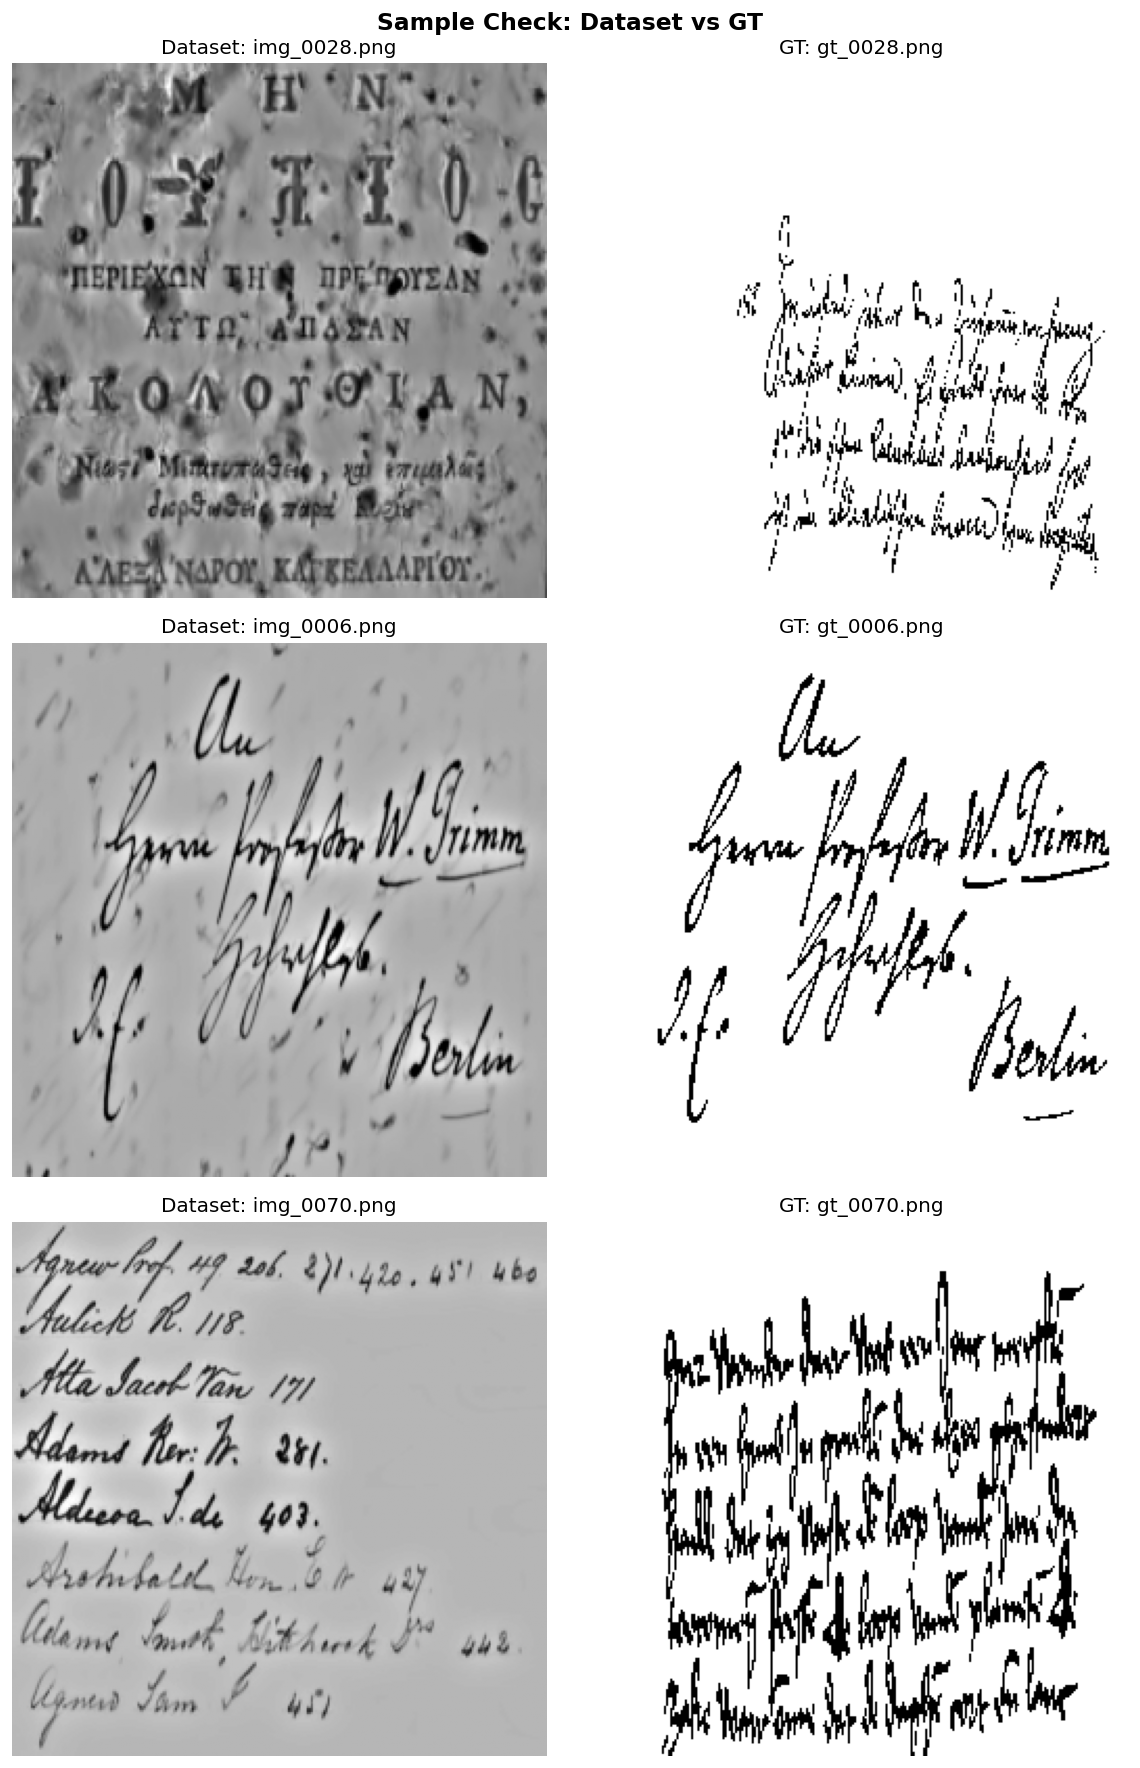

In [5]:
# Show 3 random dataset/GT pairs
random.seed(42)
n_show    = min(3, len(dataset_files), len(gt_files))
indices   = random.sample(range(min(len(dataset_files), len(gt_files))), n_show)

fig, axes = plt.subplots(n_show, 2, figsize=(10, 5 * n_show))
axes = np.array(axes).reshape(n_show, 2)  # ensure 2-D even when n_show == 1

for row, idx in enumerate(indices):
    img = cv2.imread(os.path.join(DATASET_DIR, dataset_files[idx]), cv2.IMREAD_GRAYSCALE)
    gt  = cv2.imread(os.path.join(GT_DIR,      gt_files[idx]),      cv2.IMREAD_GRAYSCALE)
    axes[row, 0].imshow(img, cmap="gray")
    axes[row, 0].set_title(f"Dataset: {dataset_files[idx]}")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(gt, cmap="gray")
    axes[row, 1].set_title(f"GT: {gt_files[idx]}")
    axes[row, 1].axis("off")

fig.suptitle("Sample Check: Dataset vs GT")
plt.tight_layout()
plt.show()

## Filter Comparison

Comparing four spatial filters on a sample image:
- **Original** — denoised during preprocessing
- **Gaussian Blur (3×3)** — smooths noise, reduces sharpness
- **Median Filter (3×3)** — removes salt-and-pepper while preserving edges
- **Mild Sharpening** — enhances edges via Laplacian kernel

Display image: img_0116.png (117/136)


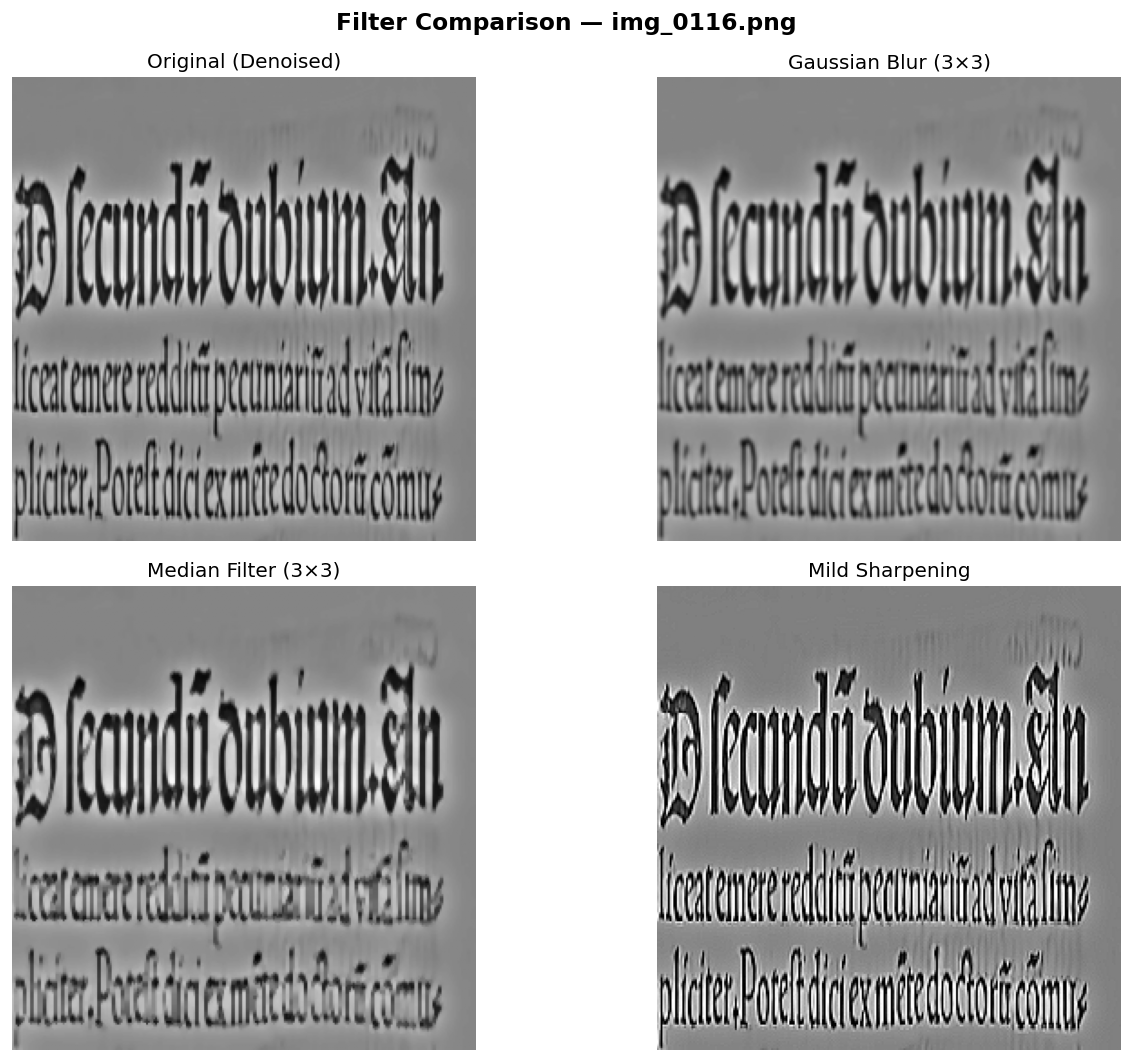

In [6]:
dataset_files = sorted(glob.glob(os.path.join(DATASET_DIR, "*.png")))
if not dataset_files:
    raise FileNotFoundError("No preprocessed images found — run the Preprocessing cell first.")

# Auto-select the most visually interesting image (highest std dev = most contrast/texture)
DISPLAY_IDX  = max(range(len(dataset_files)),
                   key=lambda i: cv2.imread(dataset_files[i], cv2.IMREAD_GRAYSCALE).std())
display_path = dataset_files[DISPLAY_IDX]
print(f"Display image: {os.path.basename(display_path)} ({DISPLAY_IDX + 1}/{len(dataset_files)})")

img           = cv2.imread(display_path, cv2.IMREAD_GRAYSCALE)
gaussian_blur = cv2.GaussianBlur(img, (3, 3), 0)
median_filt   = cv2.medianBlur(img, 3)
sharp_kernel  = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened     = cv2.filter2D(img, -1, sharp_kernel)

titles = ["Original (Denoised)", "Gaussian Blur (3×3)", "Median Filter (3×3)", "Mild Sharpening"]
images = [img, gaussian_blur, median_filt, sharpened]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, title, im in zip(axes.flat, titles, images):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
fig.suptitle(f"Filter Comparison — {os.path.basename(display_path)}")
plt.tight_layout()
plt.show()

## Binarization

Three methods suited to DIBCO degraded documents:
- **Otsu** — fast global threshold; fails on uneven illumination
- **Adaptive Gaussian** — local threshold (51px block) handles shading
- **Sauvola** — gold standard for historical documents; uses local mean & std

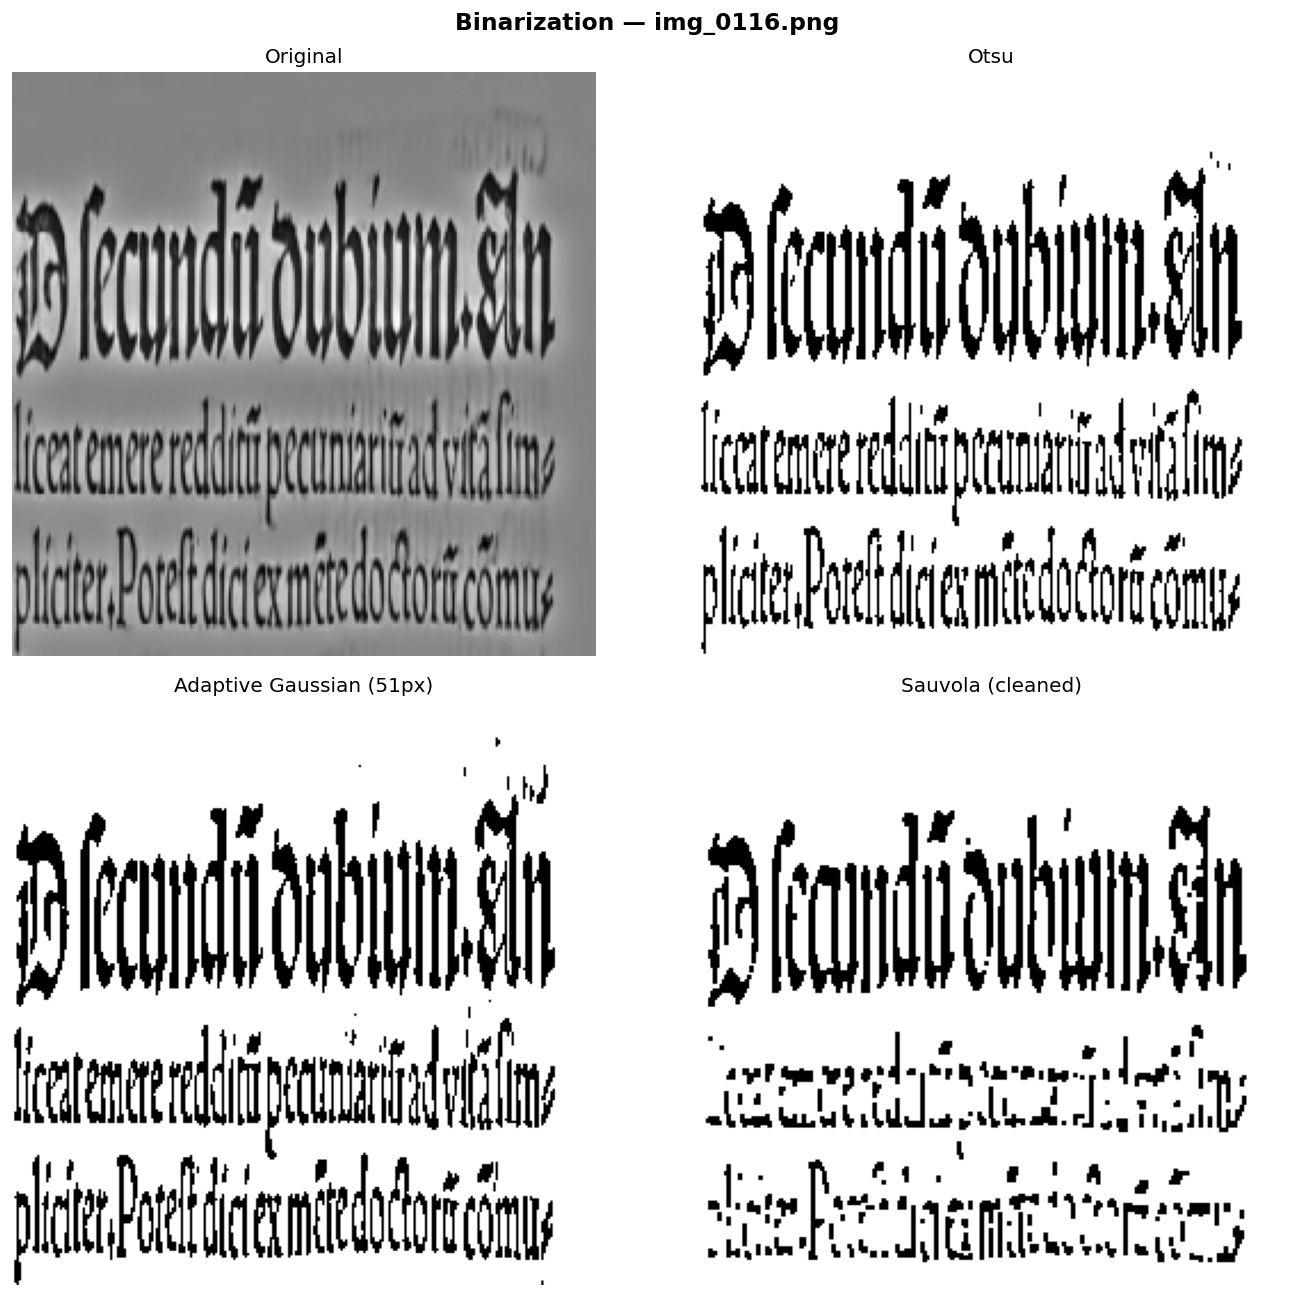

In [7]:
def sauvola_threshold(img, window=51, k=0.3, R=128):
    """Sauvola local thresholding for degraded document binarization."""
    img_f   = img.astype(np.float64)
    mean    = cv2.boxFilter(img_f, -1, (window, window))
    mean_sq = cv2.boxFilter(img_f ** 2, -1, (window, window))
    std     = np.sqrt(np.clip(mean_sq - mean ** 2, 0, None))
    thresh  = mean * (1 + k * (std / R - 1))
    return np.where(img_f < thresh, 0, 255).astype(np.uint8)

# Binarize the display image
_, bin_otsu    = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
bin_adaptive   = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY, 51, 10)
bin_sauvola    = sauvola_threshold(img)

# Light morphological cleanup on Sauvola
k2 = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
bin_sauvola_clean = cv2.morphologyEx(bin_sauvola, cv2.MORPH_OPEN,  k2)
bin_sauvola_clean = cv2.morphologyEx(bin_sauvola_clean, cv2.MORPH_CLOSE, k2)

# Save as pipeline variables
img_gray    = img
seg_cleaned = bin_sauvola_clean

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for ax, title, im in zip(axes.flat,
                         ["Original", "Otsu", "Adaptive Gaussian (51px)", "Sauvola (cleaned)"],
                         [img, bin_otsu, bin_adaptive, bin_sauvola_clean]):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
fig.suptitle(f"Binarization — {os.path.basename(display_path)}")
plt.tight_layout()
plt.show()

## Morphological Refinement

Refining the Sauvola result step-by-step:
- **Opening** — removes isolated noise pixels
- **Closing** — fills small gaps inside strokes
- **Dilation** — restores thin strokes lost during binarization

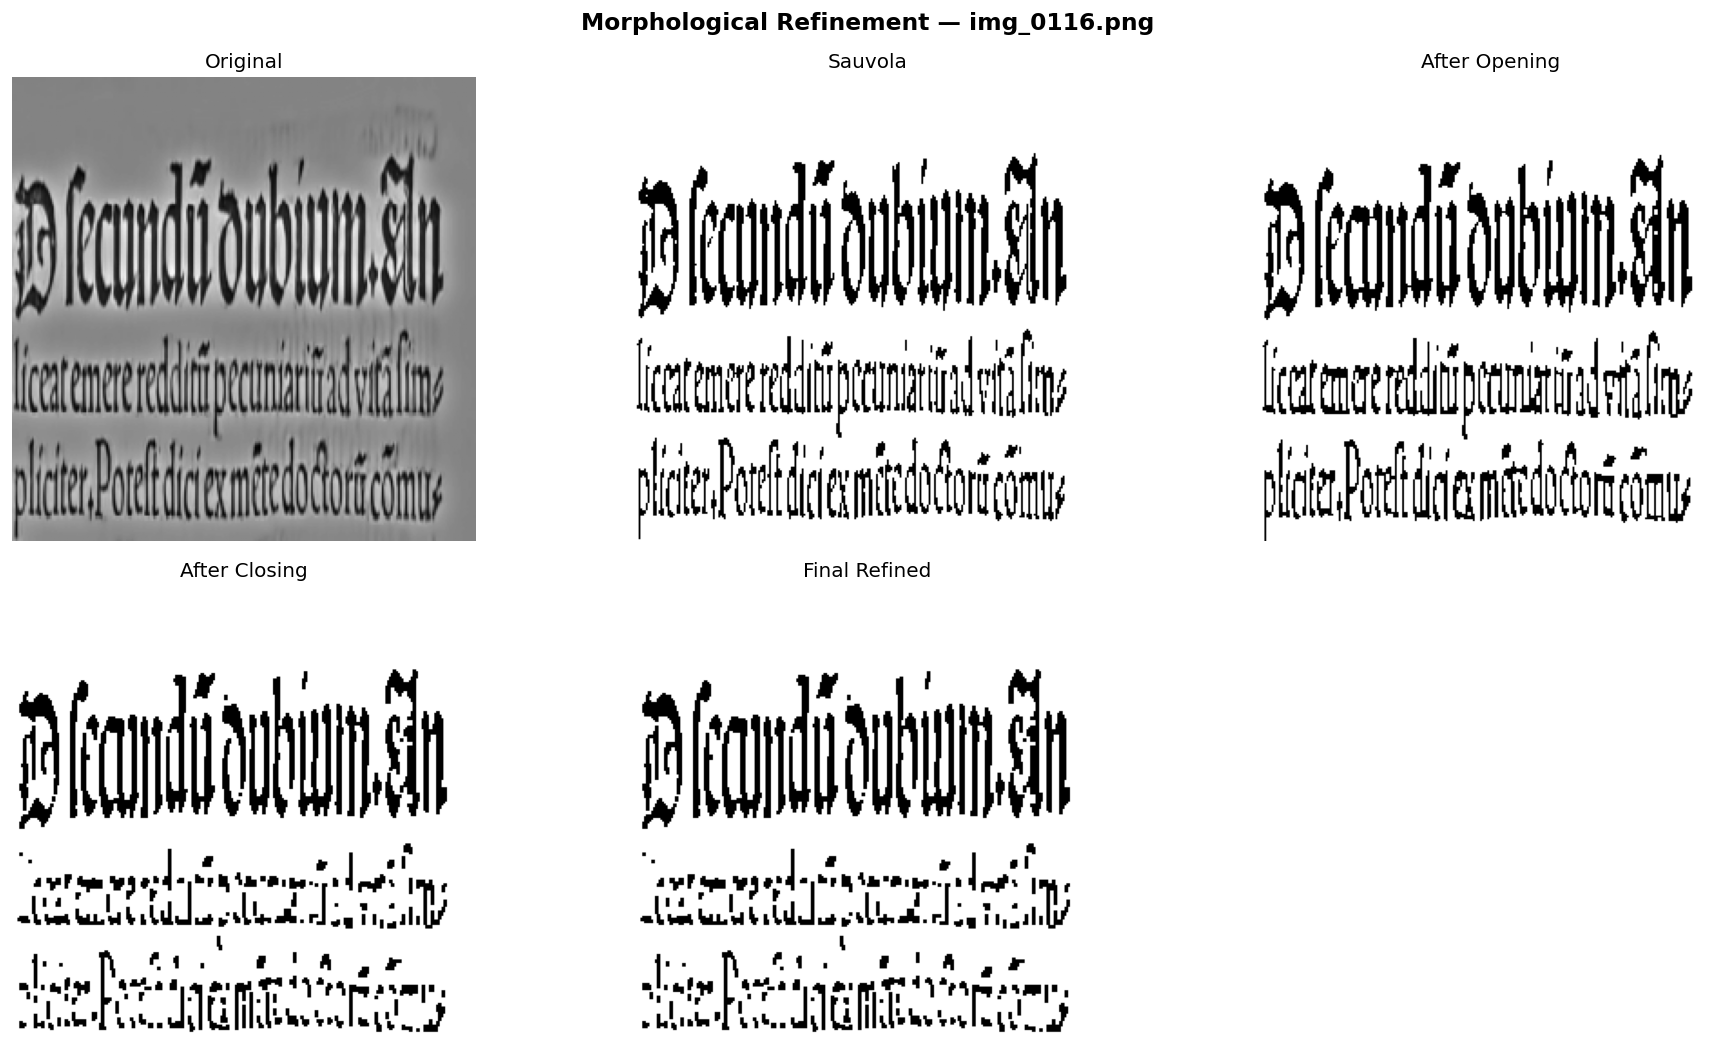

In [8]:
k2 = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
k3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

base    = sauvola_threshold(img_gray)
opened  = cv2.morphologyEx(base,   cv2.MORPH_OPEN,  k2)   # remove isolated noise pixels
closed  = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, k2)   # fill small gaps in strokes
# FIX: use open→close directly (drop the extra dilation + second close with k3
#      which was fragmenting thin strokes)
refined = closed

seg_cleaned = refined  # update for pipeline

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, title, im in zip(axes.flat,
    ["Original", "Sauvola", "After Opening", "After Closing", "Final Refined", ""],
    [img_gray, base, opened, closed, refined, np.ones_like(img_gray) * 255]):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
# hide unused 6th panel
axes.flat[5].set_visible(False)
fig.suptitle(f"Morphological Refinement — {os.path.basename(display_path)}")
plt.tight_layout()
plt.show()

## Pipeline Visualization

End-to-end summary for the display image.

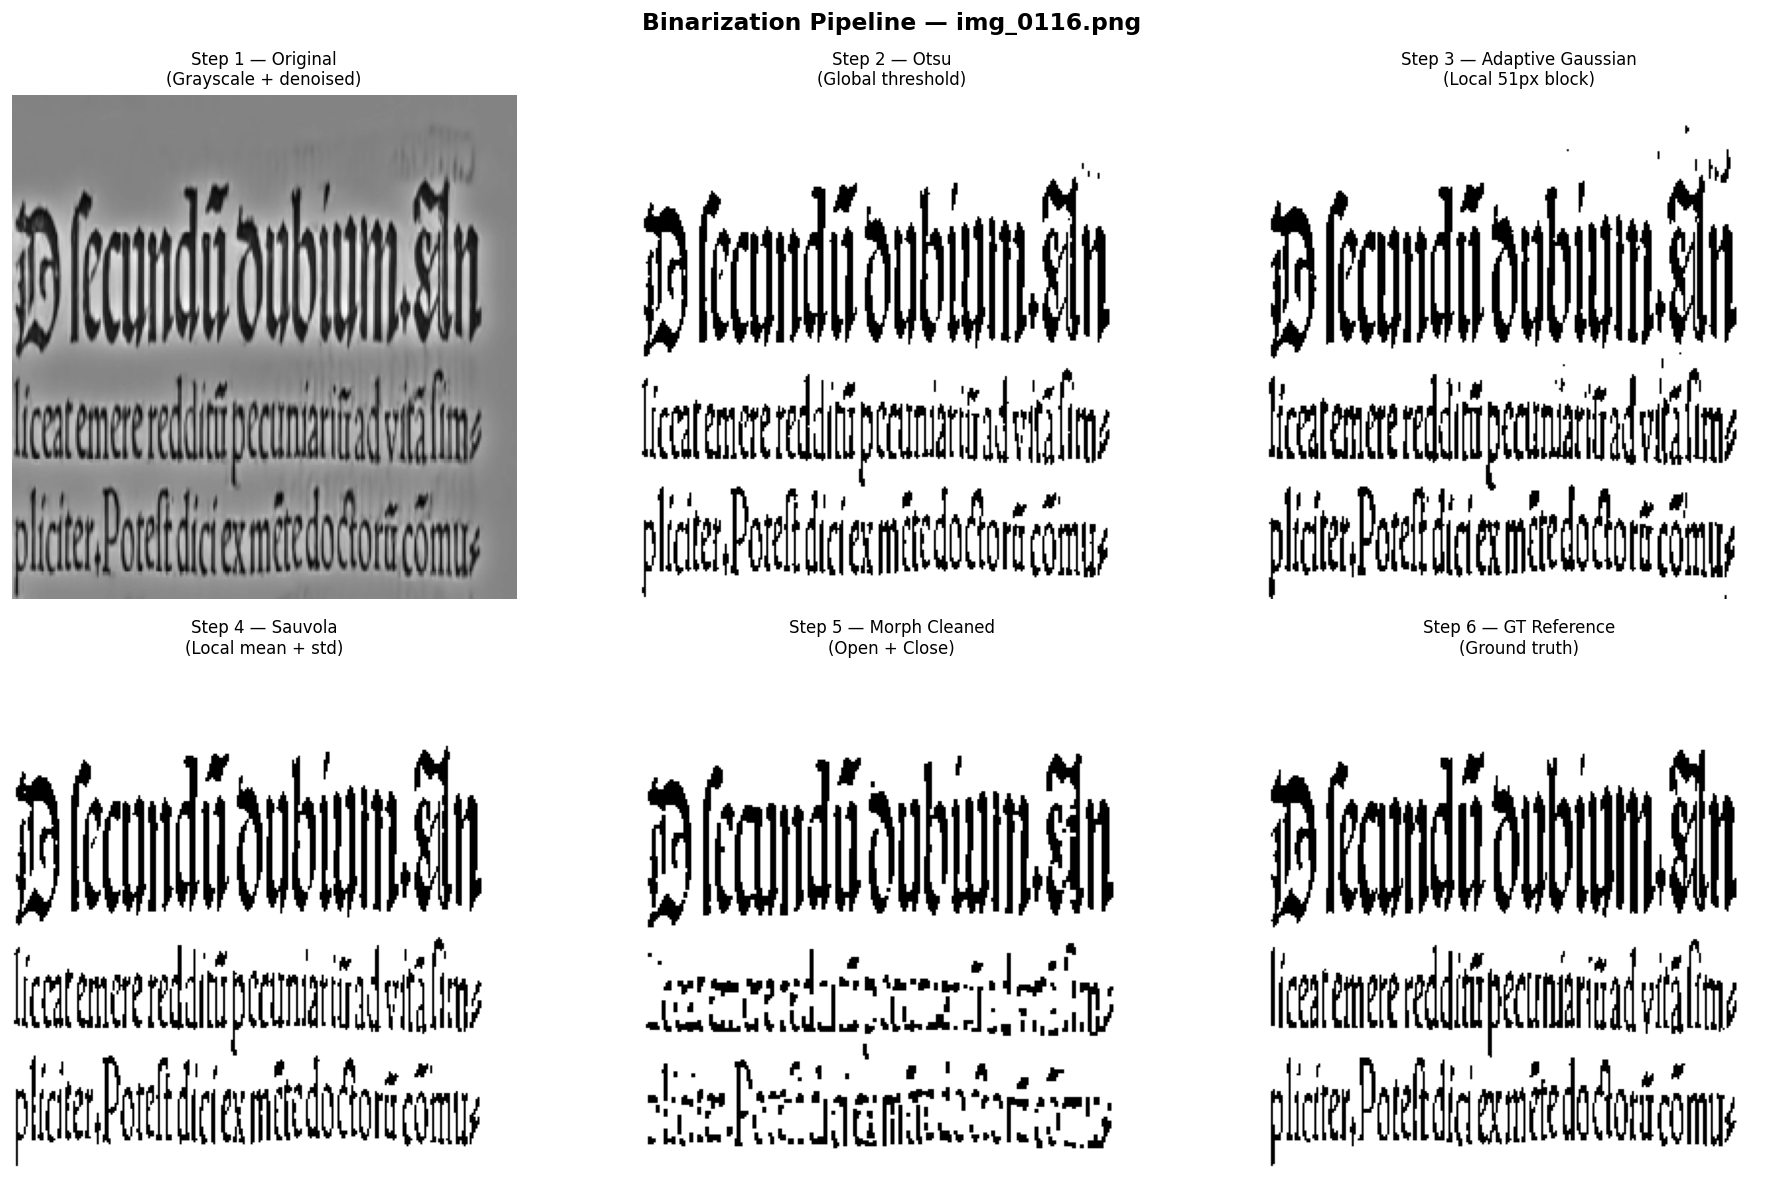

In [9]:
# Load matching GT image (same index as the dataset display image)
# BUG FIX: use a distinct variable name to avoid shadowing gt_files from the verify cell
gt_files_full = sorted(glob.glob(os.path.join(GT_DIR, "*.png")))
gt_img   = cv2.imread(gt_files_full[DISPLAY_IDX], cv2.IMREAD_GRAYSCALE) \
           if DISPLAY_IDX < len(gt_files_full) else seg_cleaned

_, otsu_step    = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
adaptive_step   = cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 51, 10)
sauvola_step    = sauvola_threshold(img_gray)

steps = [
    ("Step 1 — Original",          img_gray,      "Grayscale + denoised"),
    ("Step 2 — Otsu",              otsu_step,     "Global threshold"),
    ("Step 3 — Adaptive Gaussian", adaptive_step, "Local 51px block"),
    ("Step 4 — Sauvola",           sauvola_step,  "Local mean + std"),
    ("Step 5 — Morph Cleaned",     seg_cleaned,   "Open + Close"),
    ("Step 6 — GT Reference",      gt_img,        "Ground truth"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (title, im, desc) in zip(axes.flat, steps):
    ax.imshow(im, cmap="gray")
    ax.set_title(f"{title}\n({desc})", fontsize=10)
    ax.axis("off")
fig.suptitle(f"Binarization Pipeline — {os.path.basename(display_path)}", fontsize=14)
plt.tight_layout()
plt.show()